<h1>Predicting Rain in Australia</h1>

<h2>Table of Contents</h2>
<ul>
  <li><a href="#section1">1. Project Description</a></li>
  <li><a href="#section2">2. Data Understanding</a></li>
  <li><a href="#section3">3. Exploratory Data Analysis (EDA)</a></li>
  <li><a href="#section4">4. Data Preprocessing</a></li>
  <li><a href="#section5">5. Model Selection and Hyperparameter Tuning</a></li>
  <li><a href="#section6">6. Final Models Training & Evaluation</a></li>
  <li><a href="#section7">7. Feature Importance / Explainability</a></li>
  <li><a href="#section8">8. Conclusions & Next Steps</a></li>
</ul>

<a id='section1'></a>
## 1. Project Description

**Domain and Data Understanding**

The dataset our group uses is called “Rain in Australia.” It originates from the Australian Bureau of Meteorology and comprises about 10 years (2007–2017) of daily weather observations from locations across Australia. The data were collected from multiple weather stations and are openly accessible online (http://www.bom.gov.au/climate/data). The dataset consists of 23 attributes and approximatly 145,000 observations, including both numerical and categorical variables. Example feature groups include date and location, temperature, rainfall and related indicators, humidity, pressure, wind, and cloud cover. The main target variable (the last column) is RainTomorrow, which indicates whether it will rain on the following day. Several variables contain a substantial amount of missing values, which we will need to address during data cleaning.

**Project Statement and Goals**

Predicting rain in Australia is crucial for several reasons. Accurate rainfall forecasts are essential for planning daily activities and managing city operations, making life more predictable and convenient (Sarasa-Cabezuelo, 2022). The farming and food sectors highly depend on rainfall for planting, scheduling, and crop protection (Banik & Biswas, 2025). Because these sectors provide basic necessities for survival, farmers need to have accurate data to plan and react to upcoming weather.

Rainfall data are also important for predicting and managing extreme hydrological events (Lettenmaier, 2024). Understanding rainfall trends helps with the future prevention of flood risk and drought. Australia is a country with high climate variability; its rainfall is characterized by periods of extremely heavy rain and drought. For example, it experienced its driest 24-month period on record in the lead-up to the end of June 2020. Such a climate has strong impacts on both the environment and society (ARC Centre of Excellence for Climate Extremes, 2022).

Based on the reasons above, our main research question is:

**Given today’s weather conditions at a specific Australian location, can we predict whether it will rain tomorrow?**

We treat this as a supervised binary classification problem, where the target variable RainTomorrow indicates whether at least 1 mm of rain will fall on the following day. We also aim to identify which variables most strongly influence this dependent variable and, if necessary, to build new features by combining existing ones.

Our project consists of the following goals:
1. Understand and prepare data - Exploratory data analysis, handle missing data, and conduct additional features for later analysis
2. Build, train, and compare several machine learning models
3. Evaluate and compare model performances using suitable classification metrics
4. Interpret results and identify key weather variables strongly associated with the targeted variable

<a id='section2'></a>
## 2. Data Understanding

### 2.1 Loading Data and imports

In [1]:
# Installing needed packages
!pip install numpy pandas matplotlib seaborn folium geopy scikit-learn category-encoders lightgbm scipy

In [2]:
# CORE LIBRARIES
import numpy as np
import pandas as pd
import time

# DATA VISUALIZATION
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from geopy.geocoders import Nominatim
from geopy.exc import (
    GeocoderTimedOut,
    GeocoderUnavailable,
    GeocoderServiceError
)

# DATA PREPROCESSING
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder,
    LabelEncoder
)
from category_encoders import TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# MODEL SELECTION & SPLITTING
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV,
    cross_val_predict
)

# MACHINE LEARNING MODELS
from sklearn.ensemble import (
    RandomForestClassifier,
    IsolationForest,
    StackingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from lightgbm import LGBMClassifier

# METRICS
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    balanced_accuracy_score,
    roc_auc_score,
    accuracy_score,
    make_scorer
)

# OTHER UTILITIES
from scipy import stats
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)



In [3]:
df = pd.read_csv('weatherAUS.csv')
print(df.head())

         Date Location  MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  \
0  2008-12-01   Albury     13.4     22.9       0.6          NaN       NaN   
1  2008-12-02   Albury      7.4     25.1       0.0          NaN       NaN   
2  2008-12-03   Albury     12.9     25.7       0.0          NaN       NaN   
3  2008-12-04   Albury      9.2     28.0       0.0          NaN       NaN   
4  2008-12-05   Albury     17.5     32.3       1.0          NaN       NaN   

  WindGustDir  WindGustSpeed WindDir9am  ... Humidity9am  Humidity3pm  \
0           W           44.0          W  ...        71.0         22.0   
1         WNW           44.0        NNW  ...        44.0         25.0   
2         WSW           46.0          W  ...        38.0         30.0   
3          NE           24.0         SE  ...        45.0         16.0   
4           W           41.0        ENE  ...        82.0         33.0   

   Pressure9am  Pressure3pm  Cloud9am  Cloud3pm  Temp9am  Temp3pm  RainToday  \
0       1007.7    

### 2.2 Inspecting Data Frame

In [ ]:
# Number of observation and variables
nRows, nCols = df.shape
df.shape

In [ ]:
# Checking if there are duplicated rows
df.duplicated().sum()

#### Target Variable
RainTomorrow is a binary variable: Yes or No.

In [4]:
target = 'RainTomorrow'
print('Target:', target)

Target: RainTomorrow


#### Features

In [ ]:
# Shows the features
print('Features: ', [col for col in df.columns if col != 'RainTomorrow'])

> Aissata: paste data description table describing every feature.

In [ ]:
# Checks the data types of features and target
df.dtypes

#### Descriptive Statistics

In [ ]:
df.describe()

#### Checking Features Data Type

In [ ]:
def inspect_dataframe(df, top_n=5):
    summary = []

    for col in df.columns:
        series = df[col]
        dtype = series.dtype
        
        # Cardinality
        cardinality = series.nunique(dropna=True)
        
        # Most common values
        common_vals = series.value_counts(dropna=False).head(top_n)
        
        # Heuristic: numeric or categorical?
        if pd.api.types.is_numeric_dtype(series):
            inferred_type = "numeric"
        elif pd.api.types.is_datetime64_any_dtype(series):
            inferred_type = "datetime"
        else:
            # For object/string columns, check cardinality ratio
            ratio = cardinality / len(series)
            inferred_type = "categorical" if ratio < 0.5 else "high‑cardinality text"
        
        summary.append({
            "column": col,
            "dtype": str(dtype),
            "cardinality": cardinality,
            "inferred_type": inferred_type,
            "most_common": common_vals.to_dict()
        })

    return pd.DataFrame(summary)

inspect_dataframe(df)


Most features data type seem to be correct, except for Cloud9am and Cloud3pm.

In [ ]:
print(df["Cloud9am"])
print(df["Cloud3pm"])

We can clearly see that Cloud is a ordinal variable. We thus describe our variables as such:

In [ ]:
# Changing Cloud data types
df[["Cloud9am", "Cloud3pm"]] = df[["Cloud9am", "Cloud3pm"]].astype(object)

# Checking the data types again
df.info()

### 2.3 Definition of General Variables

In [5]:
target = 'RainTomorrow'
features = [col for col in df.columns if col != target]

numerical_features = [col for col in df.columns if col in features and df[col].dtype == 'float64']

categorical_features = [col for col in df.columns if col in features and col not in numerical_features]
# Removing date as categorical feature
if "Date" in categorical_features:
    categorical_features.remove("Date")


ordinal_categorical_features = ['Cloud3pm', 'Cloud9am']
nominal_categorical_features = list(set(categorical_features) - set(ordinal_categorical_features))

print('Target variable: ', target)
print('All features: ', features)
print('Numerical features: ', numerical_features)
print('Categorical features: ', categorical_features)
print('Ordinal categorical features: ', ordinal_categorical_features)
print('Nominal categorical features: ', nominal_categorical_features)

Target variable:  RainTomorrow
All features:  ['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainToday']
Numerical features:  ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']
Categorical features:  ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']
Ordinal categorical features:  ['Cloud3pm', 'Cloud9am']
Nominal categorical features:  ['WindGustDir', 'Location', 'WindDir9am', 'WindDir3pm', 'RainToday']


#### Helper Function

In [6]:
def evaluate_model(model_name, y_true, y_pred):
    # Detect positive class
    positive_label = 1 if y_true.dtype != object else "Yes"

    metrics = {
        "Model": model_name,
        "F1": f1_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
        "Precision": precision_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
        "Recall": recall_score(y_true, y_pred, pos_label=positive_label, zero_division=0),
        "BalancedAccuracy": balanced_accuracy_score(y_true, y_pred)
    }

    return metrics


<a id='section3'></a>
## 3. Exploratory Data Analysis (EDA)

We start with Explorator Data Analysis to explore distribution, patterns and relationships between the variables.

> Aissata: Check if df_eda is always used in this section. Already corrected some where df was used instead, but didn't check every cell.

In [ ]:
df_eda = df.copy()


### 3.1 Minimal Data Cleaning for Exploratory Data Analysis

- Missing data
- Categorical variables / features
- Inconsistent Data Types
- Detection and outliers



#### Missing Values

In [ ]:
df_eda.isna().sum()

Aissata: We have a lot of missing values. We will have to really justify what we do with these.

#### Identifying and capping outliers in numerical variables

Nils: How should we define outliers? There is a great number of 'outliers'.
Nils: Labeling of data according to Kaggel documentation

In [ ]:
def boxplot_matrix(df, nCols, nRows):
    num = df[numerical_features] # Only keeps numerical features, since boxplots are not for ordinal data.

    plt.figure(figsize=(8 * nCols, 6 * nRows)) # Creates dimensions for figure size dependent from matrix size.
    for i, col in enumerate(num.columns, 1):
        plt.subplot(nRows, nCols, i) # Creates one boxplot in each subplot.
        plt.boxplot(num[col].dropna()) # Drops NaN Value, since boxplots can't handle them.
        plt.title(col)

    plt.show()

In [ ]:
boxplot_matrix(df_eda, 4, 4) # Prints the matrix 4 by 4

In [ ]:
# Here we calculate IQR boundaries for each numeric column
for col in numerical_features:
    Q1 = df_eda[col].quantile(0.25)
    Q3 = df_eda[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    if lower < 0:
        lower = 0

    outliers = df_eda[(df_eda[col] < lower) | (df_eda[col] > upper)][col].count()
    print(f"{col}:")
    print(f" - Lower bound: {lower}")
    print(f" - Upper bound: {upper}")
    print(f" - Number of outliers: {outliers}\n")

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df_eda[['MinTemp','MaxTemp', 'Evaporation', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Temp9am', 'Temp3pm']], palette="Set2")
plt.title("Boxplot of Numerical Columns", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df_eda[['Pressure9am', 'Pressure3pm']], palette="Set2")
plt.title("Boxplot of Numerical Columns", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

#### Encoding Categorical Variables


In [ ]:
# Convert each wind direction column to an angle
wind_dirs = [
    'N', 'NNE', 'NE', 'ENE',
    'E', 'ESE', 'SE', 'SSE',
    'S', 'SSW', 'SW', 'WSW',
    'W', 'WNW', 'NW', 'NNW'
]

wind_dir_to_idx = {d: i for i, d in enumerate(wind_dirs)}

wind_dir_cols = ['WindGustDir', 'WindDir9am', 'WindDir3pm']

for col in wind_dir_cols:
    # Map text direction to index 0..15
    idx = df_eda[col].map(wind_dir_to_idx)

    # Convert index to angle in radians (0..2π)
    angle = 2 * np.pi * idx / len(wind_dirs)

    # Create sin/cos features
    df_eda[col + '_sin'] = np.sin(angle)
    df_eda[col + '_cos'] = np.cos(angle)

# Map for cloud states from 1-8. Not in use.
cloud_state= [
        'Clear sky',
        'Almost clear',
        'Mostly clear',
        'Partly cloudy',
        "Half cloudy",
        'Mostly cloudy',
        'Very cloudy',
        'Nearly overcast',
        'Overcast'
    ]

# Mapping Binary Values to values from 0 and 1
binary_map = {'No': 0, 'Yes': 1}
binary_cols = ['RainToday', 'RainTomorrow']

for col in binary_cols:
    df_eda[col] = df_eda[col].map(binary_map)

### 3.2 Univariate Analysis

#### Target Variable

Aissata: Checking target distribution to see if it is balanced or not. Will determine if we stratify or not when splitting into test and training sets.

In [ ]:
 # Creates the figure, its size, and assigns it to a variable for adding percentage labels.
plt.figure(figsize=(6, 6))
target_dis = sns.countplot(x=target, data=df_eda)

# Calculates the percentages and annotate them to the bars. First gets the number of total observations, loops throw the bars and counts the height, gives it its percentage to the total number of observations and annotate them to the bar.
total = len(df_eda)
for b in target_dis.patches:
    count = b.get_height()
    percentage = count / total * 100
    target_dis.annotate(f"{percentage:.1f}%", (b.get_x() + b.get_width() / 2, count)) # Gets the position of the annotation.

# Adds labels and prints the figure
plt.title("Distribution of Rain Tomorrow", fontsize=14)
plt.xlabel("Status of Rain Tomorrow")
plt.ylabel("Number of Observations")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("Target distribution:")
print(df[target].value_counts(normalize=True))  # relative frequencies

Since Target is imbalanced, we will apply stratification when splitting the data.

In [ ]:
df.hist(figsize=(25, 25))
plt.show()

#### Categorical Variables Analysis
For the analysis of all categorical variables we will do the following:
- Map encoded numerica values back to text labels (Nils: first we need to encode them properly lol
- Apply mapping to create human-readable labels
- Plot distribution

##### Location

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(x=df_eda['Location'])
plt.title('Distribution of Location', fontsize=14)
plt.xlabel('Locations')
plt.ylabel('Number of Observations')
plt.xticks(rotation=90)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

##### Rain Amount by Location

In [ ]:
# Aggregate rainfall by location into dataframe and resets index
df_rain_by_location = df_eda.groupby("Location", as_index=False)["Rainfall"].mean()

In [ ]:
geolocator = Nominatim(user_agent="parser_rain_locations")

def get_geocode(location, country="Australia", sleep=1):
    loc = geolocator.geocode(f"{location}, {country}")
    time.sleep(sleep)  # server time out
    if loc is None:
        return pd.Series({"Latitude": None, "Longitude": None})
    return pd.Series({"Latitude": loc.latitude, "Longitude": loc.longitude})

df_rain_by_location[["Latitude", "Longitude"]] = (
    df_rain_by_location["Location"]
    .astype(str)
    .apply(get_geocode)
)

df_rain_by_location

In [ ]:
# Drops NaN values for visualization
df_rain_by_location_clean = df_rain_by_location.dropna(subset=["Latitude", "Longitude"]).copy()

# Normalize Rainfall for scaling
scaler = MinMaxScaler(feature_range=(4, 30))
df_rain_by_location_clean['Rainfall_norm'] = scaler.fit_transform(df_rain_by_location_clean[['Rainfall']])


# Creates a map with the locations and dynamic bubbles sizes. For that we normalize rainfall.
map_australia = folium.Map(location=[-25.2744, 133.7751], zoom_start=5)

# Creates the bubbles on the map
for _, row in df_rain_by_location_clean.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=row['Rainfall_norm'],
        fill=True,
        fill_opacity=0.7,
        weight=1,
        popup=f'{row['Location']}<br>Rainfall: {row['Rainfall']:.2f}'
    ).add_to(map_australia)

map_australia

##### Wind Gust Direction

> match this to some kind of degree circle

In [ ]:
WindGustDir_order = [
        'N', 'NNE', 'NE', 'ENE',
        'E', 'ESE', 'SE', 'SSE',
        'S', 'SSW', 'SW', 'WSW',
        'W', 'WNW', 'NW', 'NNW'
        ]

plt.figure(figsize=(10, 6))
sns.countplot(x=df_eda['WindGustDir'], order=WindGustDir_order)
plt.title('Distribution of Wind Gust Direction', fontsize=14)
plt.xlabel('Direction')
plt.ylabel('Number of Observations')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

The polar histogram shows that, on days when rain occurs the following day (RainTomorrow = Yes), wind gusts most frequently originate from the northern and western sectors, while easterly directions are less common. This suggests that certain synoptic wind regimes are associated with rainy conditions. However, the plot only reflects the distribution of wind directions conditional on rain; without comparing it to the distribution on non-rainy days, we cannot conclude that these directions actually increase the probability of rain.

In [ ]:
WindGustDir_order = [
    'N', 'NNE', 'NE', 'ENE',
    'E', 'ESE', 'SE', 'SSE',
    'S', 'SSW', 'SW', 'WSW',
    'W', 'WNW', 'NW', 'NNW'
]

# Filter to days where RainTomorrow = 'Yes'
df_rain = df_eda[df_eda['RainTomorrow'] == 'Yes']

# Count how often each direction appears
dir_counts = (
    df_rain['WindGustDir']
    .value_counts()
    .reindex(WindGustDir_order)
    .fillna(0)
)

n_dirs = len(WindGustDir_order)
angles = np.linspace(0, 2 * np.pi, n_dirs, endpoint=False)
heights = dir_counts.values

plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

width = 2 * np.pi / n_dirs
ax.bar(angles, heights, width=width, align='center')

# Compass-style orientation
ax.set_theta_zero_location('N')   # put 0° at North (top)
ax.set_theta_direction(-1)        # clockwise

ax.set_xticks(angles)
ax.set_xticklabels(WindGustDir_order)

ax.set_title('Distribution of Wind Gust Direction (polar) with Rain Tomorrow = Yes', fontsize=14, pad=20)
ax.set_yticklabels([])

plt.tight_layout()
plt.show()


##### Wind Direction 9am

>Same

In [ ]:
WindDir9am_order = [
        'N', 'NNE', 'NE', 'ENE',
        'E', 'ESE', 'SE', 'SSE',
        'S', 'SSW', 'SW', 'WSW',
        'W', 'WNW', 'NW', 'NNW'
        ]

plt.figure(figsize=(10, 6))
sns.countplot(x=df_eda['WindDir9am'], order=WindDir9am_order)
plt.title('Distribution of Wind Direction at 9am', fontsize=14)
plt.xlabel('Direction')
plt.ylabel('Number of Observations')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

The polar plot of wind direction at 9 a.m. on days with RainTomorrow = Yes shows that winds are most frequently northerly, with additional contributions from north-westerly sectors, while easterly and southerly winds are comparatively rare. This suggests that certain wind patterns may be associated with next-day rainfall. However, since the plot only shows wind directions conditional on rain, further analysis is needed—e.g., comparing with the wind distribution on non-rain days and examining specific stations or regions—to assess whether these directions truly increase the likelihood of rain.

In [ ]:
# Distribution of Wind Direction at 9am (polar)
WindDir9am_order = [
    'N', 'NNE', 'NE', 'ENE',
    'E', 'ESE', 'SE', 'SSE',
    'S', 'SSW', 'SW', 'WSW',
    'W', 'WNW', 'NW', 'NNW'
]

# Filter to days where RainTomorrow = 'Yes'
df_rain = df_eda[df_eda['RainTomorrow'] == 'Yes']

# Count how often each 9am direction appears, in the defined order
dir9_counts = (
    df_rain['WindDir9am']
    .value_counts()
    .reindex(WindDir9am_order)
    .fillna(0)
)

# Prepare angles and heights
n_dirs = len(WindDir9am_order)
angles = np.linspace(0, 2 * np.pi, n_dirs, endpoint=False)
heights = dir9_counts.values

# Polar bar plot
plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

width = 2 * np.pi / n_dirs
bars = ax.bar(angles, heights, width=width, align='center')

# Compass-style orientation
ax.set_theta_zero_location('N')   # put 0° at North (top)
ax.set_theta_direction(-1)        # clockwise

ax.set_xticks(angles)
ax.set_xticklabels(WindDir9am_order)

ax.set_title('Distribution of Wind Direction at 9am with Rain Tomorrow = Yes (polar)', fontsize=14, pad=20)
ax.set_yticklabels([])

plt.tight_layout()
plt.show()

##### Wind Direction 3pm

> same

In [ ]:
WindDir3pm_order = [
        'N', 'NNE', 'NE', 'ENE',
        'E', 'ESE', 'SE', 'SSE',
        'S', 'SSW', 'SW', 'WSW',
        'W', 'WNW', 'NW', 'NNW'
        ]

plt.figure(figsize=(10, 6))
sns.countplot(x=df_eda['WindDir3pm'], order=WindDir3pm_order)
plt.title('Distribution of Wind Direction at 3pm', fontsize=14)
plt.xlabel('Direction')
plt.ylabel('Number of Observations')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

The polar plot of wind direction at 3 p.m. on days with RainTomorrow = Yes shows that winds most frequently blow from northerly to westerly sectors, whereas easterly winds are less common. This pattern suggests a possible link between these wind regimes and next-day rainfall. However, we still need to compare this distribution with non-rain days and across different locations to confirm whether these directions truly correlate with RainTomorrow = Yes or whether the pattern is region-specific.

In [ ]:
# Distribution of Wind Direction at 3pm (polar)
WindDir3pm_order = [
    'N', 'NNE', 'NE', 'ENE',
    'E', 'ESE', 'SE', 'SSE',
    'S', 'SSW', 'SW', 'WSW',
    'W', 'WNW', 'NW', 'NNW'
]

# Filter to days where RainTomorrow = 'Yes'
df_rain = df_eda[df_eda['RainTomorrow'] == 'Yes']

# 1) Count how often each 3pm direction appears, in the defined order
dir3_counts = (
    df_rain['WindDir3pm']
    .value_counts()
    .reindex(WindDir3pm_order)
    .fillna(0)
)

# 2) Prepare angles (around the circle) and heights (counts)
n_dirs = len(WindDir3pm_order)
angles = np.linspace(0, 2 * np.pi, n_dirs, endpoint=False)
heights = dir3_counts.values

# 3) Polar bar plot
plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

width = 2 * np.pi / n_dirs   # angular width of each bar
bars = ax.bar(angles, heights, width=width, align='center')

# Compass-style orientation
ax.set_theta_zero_location('N')   # put 0° at North (top)
ax.set_theta_direction(-1)        # clockwise

# 4) Put the direction labels around the circle
ax.set_xticks(angles)
ax.set_xticklabels(WindDir3pm_order)

ax.set_title('Distribution of Wind Direction at 3pm with Rain Tomorrow = Yes (polar)', fontsize=14, pad=20)
ax.set_yticklabels([])  # hide radial numbers if you want a clean look

plt.tight_layout()
plt.show()

##### Rain Today

> percentage again. time series? count rain days per month?

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x=df_eda['RainToday'])
plt.title('Distribution of Rain Today', fontsize=14)
plt.xlabel('Status of Rain Today')
plt.ylabel('Number of Observations')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

##### Cloud 9am

In [ ]:
# does not show any data. will correct

Cloud9am_order = [
        'Clear sky',
        'Almost clear',
        'Mostly clear',
        'Partly cloudy',
        "Half cloudy",
        'Mostly cloudy',
        'Very cloudy',
        'Nearly overcast',
        'Overcast'
    ]

plt.figure(figsize=(10, 6))
sns.countplot(x=df_eda['Cloud9am'], order=Cloud9am_order)
plt.title('Distribution of Cloud at 9am')
plt.xlabel('Cloud at 9am (Oktas)')
plt.ylabel('Number of Observations')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

#### Numerical Variables Analysis

##### MinTemp

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(x=df_eda['MinTemp'], bins=30)
plt.title('Distribution of Minimum Temperature')
plt.xlabel('Minimum Temperature (C°)')
plt.ylabel('Number of Observations')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

##### Maximum Temperature

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(x=df_eda['MaxTemp'], bins=30)
plt.title('Distribution of Maximum Temperature')
plt.xlabel('Maximum Temperature (C°)')
plt.ylabel('Number of Observations')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

##### Rainfall

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(x=df_eda['Rainfall'], bins=30)
plt.title('Distribution of Rainfall')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Number of Observations')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [ ]:
# filter rainfall histogram in an upper set to better display the distribution above 50mm

plt.figure(figsize=(10, 6))
plt.hist(x=df_eda[df_eda['Rainfall'] > 50]['Rainfall'], bins=30)
plt.title('Distribution of Rainfall above 50mm for visibility')
plt.xlabel('Rainfall above 50mm (mm)')
plt.ylabel('Number of Observations')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()


In [ ]:
sns.boxplot(x=df_eda['Rainfall'])
plt.title('Distribution of Rainfall')
plt.show()

##### Evaporation

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(x=df_eda['Evaporation'], bins=30)
plt.title('Distribution of Evaporation')
plt.xlabel('Evaporation')
plt.ylabel('Number of Observations')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [ ]:
# filter rainfall histogram in an upper set to better display the distribution above 50mm
# Nils: should the threshold (20) follow some methodology?

plt.figure(figsize=(10, 6))
plt.hist(x=df_eda[df_eda['Evaporation'] > 20]['Evaporation'], bins=30)
plt.title('Distribution of Evaporation above 20mm for visibility')
plt.xlabel('Evaporation')
plt.ylabel('Number of Observations')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

##### Sunshine

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(x=df_eda['Sunshine'], bins=24)
plt.title('Distribution of Sunshine')
plt.xlabel('Sunshine (h)')
plt.ylabel('Number of Observations')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

##### Wind Gust Speed

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(x=df_eda['WindGustSpeed'], bins=30)
plt.title('Distribution of Wind Gust Speed')
plt.xlabel('Wind Gust Speed (km/h)')
plt.ylabel('Number of Observations')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(x=df_eda[df_eda['WindGustSpeed'] > 100 ]['WindGustSpeed'], bins=30)
plt.title('Distribution of Wind Gust Speed above 100 km/h')
plt.xlabel('Wind Gust Speed above 100 km/h (km/h)')
plt.ylabel('Number of Observations')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

##### Wind Speed at 9am

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(x=df_eda['WindSpeed9am'], bins=30)
plt.title('Distribution of Wind Speed at 9am')
plt.xlabel('Wind Speed at 9am (km/h)')
plt.ylabel('Number of Observations')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

##### Wind Speed at 3pm

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(x=df_eda['WindSpeed3pm'], bins=30)
plt.title('Distribution of Wind Speed at 3pm')
plt.xlabel('Wind Speed at 3pm (km/h)')
plt.ylabel('Number of Observations')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

##### Humidity 9am

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(x=df_eda['Humidity9am'], bins=100)
plt.title('Distribution of Humidity at 9am')
plt.xlabel('Humidity at 9am (%)')
plt.ylabel('Number of Observations')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

##### Humanidity 3pm

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(x=df_eda['Humidity3pm'], bins=100)
plt.title('Distribution of Humidity at 3pm')
plt.xlabel('Humidity at 3pm (%)')
plt.ylabel('Number of Observations')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

##### Pressure 9am

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(x=df_eda['Pressure9am'], bins=30)
plt.title('Distribution of Pressure at 9am')
plt.xlabel('Pressure at 9am (Pa)')
plt.ylabel('Number of Observations')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

##### Pressure 3pm

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(x=df_eda['Pressure3pm'], bins=30)
plt.title('Distribution of Pressure at 3pm')
plt.xlabel('Pressure at 3pm (hpa)')
plt.ylabel('Number of Observations')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

##### Temperature 9am

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(x=df_eda['Temp9am'], bins=40)
plt.title('Distribution of Temperature at 9am')
plt.xlabel('Temperature (C°)')
plt.ylabel('Number of Observations')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

##### Temperature 3pm

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(x=df_eda['Temp3pm'], bins=40)
plt.title('Distribution of Temperature at 3pm')
plt.xlabel('Temperature (C°)')
plt.ylabel('Number of Observations')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

Jessica:
>Rain Days by time Rain Amount by time Wind Speed by time Sunshine by time

Nils:
>Rain Amount or Rain Days by location Wind Speed by month and location Sunshine by location

In [ ]:
# Preparing for time-related analysis

# Define RainDay based on RainToday (different kinds of "yes" will all be considered)
df_eda['RainDay'] = df_eda['RainToday'].astype(str).str.strip().str.lower() == 'yes'
print(df_eda['RainToday'].value_counts(dropna=False))
print(df_eda['RainDay'].value_counts(dropna=False))

# The date variable is a code-readable date and time
df_eda["Date"] = pd.to_datetime(df_eda['Date'])

# Extract month from Date
df_eda['Month'] = df_eda['Date'].dt.month

# Extract year from Date
df_eda['Year'] = df_eda['Date'].dt.year

# Month x-axis settings for later
month_positions = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

##### Rain days by month

The bar chart currently counts all rainy observations per month across all stations, so the y-axis reflects the number of location-days with rain rather than the number of distinct rainy calendar days. Because multiple locations report on the same date, this aggregation overestimates the apparent number of “rainy days”. A more meaningful analysis would either focus on individual locations or compute monthly averages per station (e.g. the average fraction of rainy days per month by location).

In [ ]:
# Count rainy days per month
rain_counts = df_eda['Month'].value_counts().sort_index()

# Plot (bar chart of rainy days per month)
plt.figure(figsize=(10, 6))
plt.bar(rain_counts.index, rain_counts.values)

plt.xticks(
    ticks=month_positions,
    labels=month_labels,
    fontsize=12
)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Number of rainy days', fontsize=14)
plt.title('Rainy Days per Month', fontsize=16)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

##### Rainy days per year

The bar chart of rainy days per year shows very few observations in 2007, 2008, and 2017. This likely reflects incomplete coverage for those years (late start of data collection, early termination, or missing records), so we do not interpret these three years further. For the remaining years, rainfall occurrence is relatively stable, with slightly higher counts around 2010 and 2016 and a local minimum in 2012. However, these values aggregate observations from many stations, so they represent the total number of location-days with rain rather than distinct rainy calendar days. A more detailed analysis by individual location (or region) would be needed to draw meaningful conclusions about temporal trends in rainfall.

In [ ]:
# Count rainy days per year
rain_counts_year = (df_eda[df_eda['RainDay']].groupby('Year').size())

print(rain_counts_year)

# Plot (bar chart of rainy days per year)
plt.figure(figsize=(10, 6))
plt.bar(rain_counts_year.index, rain_counts_year.values)

plt.xticks(rain_counts_year.index, fontsize=12, rotation=45)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Number of rainy days', fontsize=14)
plt.title('Rainy Days per Year', fontsize=16)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

##### Average Rain Amount by month

The bar chart of average daily rainfall by month shows a clear seasonal pattern, with peak rainfall in February and a minimum around October. Since Australia is in the Southern Hemisphere, this aligns with higher rainfall during the austral summer (approximately December–March). However, the dataset aggregates observations from many stations spanning very different climate zones, so this pattern represents an overall average. To understand regional rainfall regimes more accurately, it would be preferable to repeat this analysis separately by location or climate region.

In [ ]:
# Average rainfall per month (across all years)
mean_rain_month = df_eda.groupby('Month')['Rainfall'].mean()

plt.figure(figsize=(10, 6))
plt.bar(mean_rain_month.index, mean_rain_month.values)

plt.xticks(
    ticks=month_positions,
    labels=month_labels,
    fontsize=12
)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Average Rainfall (mm per day)', fontsize=14)
plt.title('Average Rainfall amount by Month', fontsize=16)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

##### Average Rain Amount by year

The figure shows the average daily rainfall per year across all stations. Consistent with the previous “rainy days per year” plot, 2007, 2008 and 2017 likely suffer from incomplete coverage, so those years should be treated with caution or excluded from interpretation. For the remaining period (2009–2016), average rainfall fluctuates rather than showing a clear long-term trend: values increase from 2009 to a local maximum around 2010–2011, then decline to a minimum in 2013–2014, followed by a modest recovery afterwards. Because these averages combine many stations from very different climate regions, this plot is mainly useful for visualising the overall variability of rainfall in the dataset; more detailed insights would require analysing trends separately by location or region.

In [ ]:
# Average rainfall per year (across all days)
mean_rain_year = df_eda.groupby('Year')['Rainfall'].mean().sort_index()

print(mean_rain_year)

# Plot
plt.figure(figsize=(10, 6))
plt.bar(mean_rain_year.index, mean_rain_year.values)

plt.xticks(mean_rain_year.index, fontsize=12, rotation=45)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Average Rainfall (mm per day)', fontsize=14)
plt.title('Average Daily Rainfall by Year', fontsize=16)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

##### average wind speed by month

The bar chart shows that average daily gust speeds across all stations lie roughly between 40 and 50 km/h, with a minimum around April–June (≈ 42–44 km/h) and a maximum close to 50 km/h in August–October. Compared with the earlier plot of average monthly rainfall, where rainfall peaks in February–April, there is no obvious alignment between higher gust speeds and higher rainfall totals. This plot alone therefore does not suggest a simple seasonal relationship between gust speed and rainfall; a more detailed analysis (e.g. comparing gust speeds on rainy vs. non-rainy days or examining specific regions) would be needed to assess any association.

In [ ]:
avg_gust_month = df_eda[df_eda['RainTomorrow'] == 'Yes'].groupby('Month')['WindGustSpeed'].mean().sort_index()

plt.figure(figsize=(10, 6))
plt.bar(avg_gust_month.index, avg_gust_month.values)

plt.xticks(month_positions, month_labels, fontsize=12)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Average Gust speed', fontsize=14)
plt.title('Average Gust Speed by Month with Rain Tomorrow = yes', fontsize=16)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

##### average wind speed by year

Excluding 2007, 2008 and 2017, which likely suffer from incomplete data coverage as discussed above, the average gust speed on days with RainTomorrow = Yes remains fairly stable over time, generally between 44 and 48 km/h. There is no clear long-term increasing or decreasing trend, suggesting that, in this dataset, year-to-year variability in next-day rainfall is not driven by systematic changes in gust strength.

In [ ]:
avg_gust_year = df_eda[df_eda['RainTomorrow'] == 'Yes'].groupby('Year')['WindGustSpeed'].mean().sort_index()

plt.figure(figsize=(10, 6))
plt.bar(avg_gust_year.index, avg_gust_year.values)

plt.xticks(avg_gust_year.index, fontsize=12, rotation=45)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Average gust speed (km/h)', fontsize=14)
plt.title('Average Gust Speed by Year with Rain Tomorrow = yes', fontsize=16)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

##### average hours of sunshine per day in month

In [ ]:
# Look at general sunshine stats
print(df_eda['Sunshine'].describe())

# Group by Month and calculate the average Sunshine
avg_sunshine_per_month = df_eda.groupby('Month')['Sunshine'].mean()

# Sort the result by month number (1 to 12)
avg_sunshine_per_month = avg_sunshine_per_month.sort_index()

print(avg_sunshine_per_month)

# Plot chart
plt.figure(figsize=(10, 6))
plt.bar(avg_sunshine_per_month.index, avg_sunshine_per_month.values)

plt.xticks(
    ticks=month_positions,
    labels=month_labels,
    fontsize=12
)
plt.xlabel('Month', fontsize=14)
plt.ylabel('Average sunshine hours per day', fontsize=14)
plt.title('Average Daily Sunshine by Month', fontsize=16)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

##### average hours of sunshine per day in year

In [ ]:
# Group by Year and calculate the average Sunshine
avg_sunshine_per_year = df_eda.groupby('Year')['Sunshine'].mean()

# Sort the result by year (just to be safe)
avg_sunshine_per_year = avg_sunshine_per_year.sort_index()

print(avg_sunshine_per_year)

# Plot chart
plt.figure(figsize=(10, 6))
plt.bar(avg_sunshine_per_year.index, avg_sunshine_per_year.values)

plt.xticks(avg_sunshine_per_year.index, fontsize=12, rotation=45)
plt.xlabel('Year', fontsize=14)
plt.ylabel('Average sunshine hours per day', fontsize=14)
plt.title('Average Daily Sunshine by Year', fontsize=16)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

> add comments to why is meaningful or not

### Bivariate Analysis

### Correlation Analysis

In [ ]:
cols_for_corr = [
    'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
    'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm',
    'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm',
    'Cloud9am', 'Cloud3pm',
]

df_corr = df[cols_for_corr]

corr_matrix = df_corr.corr()

fig, ax = plt.subplots(figsize=(20,16))
sns.heatmap(corr_matrix, annot=True, ax=ax, linewidth =.5,annot_kws={"fontsize":14})

"""
MinTemp          float64
MaxTemp          float64
Rainfall         float64
Evaporation      float64
Sunshine         float64
WindGustSpeed    float64
WindSpeed9am     float64
WindSpeed3pm     float64
Humidity9am      float64
Humidity3pm      float64
Pressure9am      float64
Pressure3pm      float64
Cloud9am         float64
Cloud3pm         float64
Temp9am          float64
Temp3pm          float64
"""

In [ ]:
# select variables that I care about
cols_for_pairplot = [
    'MinTemp',
    'MaxTemp',
    'Rainfall',
    'Humidity3pm',
    'Pressure3pm',
    'Temp3pm',
    'Cloud9am',
    'Cloud3pm'
]

In [ ]:
# Split the dataframe into Yes / No subsets
# Subset for RainTomorrow = Yes
df_yes = df_eda[df_eda['RainTomorrow'] == 'Yes'][cols_for_pairplot].dropna()

# Subset for RainTomorrow = No
df_no = df_eda[df_eda['RainTomorrow'] == 'No'][cols_for_pairplot].dropna()

In [ ]:
# Pairplot for RainTomorrow = Yes
g_yes = sns.pairplot(
    df_yes,
    corner=True,
    plot_kws={'alpha': 0.4, 's': 15}
)
g_yes.fig.suptitle('Scatter Matrix – RainTomorrow = Yes', y=1.02, fontsize=18)
plt.show()

In [ ]:
# Pairplot for RainTomorrow = No
g_no = sns.pairplot(
    df_no,
    corner=True,
    plot_kws={'alpha': 0.4, 's': 15}
)
g_no.fig.suptitle('Scatter Matrix – RainTomorrow = No', y=1.02, fontsize=18)
plt.show()

> seperate rain tomorow yes/no

<a id='section4'></a>
## 4. Data Preprocessing


<a id="split-data"></a>
### 4.1 Split Data into Test and Validation Sets

#### Preliminary Operations: Data Reloading, Feature Engineering, and High-Cardinality Categorical Feature Handling

In [7]:
# Reloading Data
df = pd.read_csv('weatherAUS.csv')
# Converting date to datetime format
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["Weekday"] = df["Date"].dt.weekday
df = df.drop(columns=["Date"])
# Converting Cloud columns to object data types
df[['Cloud9am', 'Cloud3pm']] = df[['Cloud9am', 'Cloud3pm']].astype('object')
# Dropping rows with missing target values
df = df.dropna(subset=['RainTomorrow']).copy()

# Detect nominal features with high-cardinality
HIGH_CARDINALITY_THRESHOLD = 10
high_card_features = [
    (col, df[col].nunique())
    for col in nominal_categorical_features
    if df[col].nunique() > HIGH_CARDINALITY_THRESHOLD
]

# Separate low/high-cardinality nominal columns
low_card_features = [col for col in categorical_features if col not in [c for c, _ in high_card_features]]
high_card_features_names = [col for col, _ in high_card_features]

print("High-cardinality features:", high_card_features_names)
print("Low-cardinality features: ",low_card_features)

High-cardinality features: ['WindGustDir', 'Location', 'WindDir9am', 'WindDir3pm']
Low-cardinality features:  ['RainToday']


We first reloaded and preprocessed the raw data. We used pd.read_csv('weatherAUS.csv') to load the dataset, converted Date to datetime format (with errors="coerce" to avoid errors caused by invalid dates), and extracted four time features from it, including Year, Month, Day, and Weekday, to capture possible seasonal and periodic effects. Then we dropped the original Date column to reduce redundancy. At the same time, we explicitly converted Cloud9am and Cloud3pm to the object type so that they would be treated as categorical variables and encoded as such in later steps. We also removed samples with missing target values in RainTomorrow to ensure the labels are complete for supervised learning.

Next, to avoid a very large feature space caused by One-Hot encoding on nominal categorical variables, we set a high-cardinality threshold HIGH_CARDINALITY_THRESHOLD = 10 and grouped nominal categorical features based on the number of unique values. If a feature has nunique() > 10, we treat it as a high-cardinality feature. The results show that the high-cardinality features are ['Location', 'WindGustDir', 'WindDir3pm', 'WindDir9am'], and the low-cardinality features are ['Cloud9am', 'Cloud3pm', 'RainToday']. This grouping supports our later encoding strategy. Low-cardinality features are suitable for One-Hot or ordinal encoding, while high-cardinality features are better handled with Target Encoding. In this way, we can control the feature dimension while keeping useful information, and also improve training efficiency and model stability.

#### Splitting data

In [8]:
# Dropping missing values, as it lead to better model performance in preliminary experiments
df_clean = df.dropna().reset_index(drop=True)

# Define features matrix X and target vector y
y = df_clean[target]
X = df_clean.drop(columns=[target])

# First split into (train + val) and test sets - 80% (train + val), 20% test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # or use stratify=y because target is categorical/imbalanced
)

# Then split again (train + val) into train and validation sets - 75% train, 25% val of remaining 80%
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25,  # 0.25 * 0.8 = 0.2 of original data for validation
    random_state=42,
    stratify=y_train_val
)


print(f"Train size: {X_train.shape[0]}")
print(f"Validation size: {X_val.shape[0]}")
print(f"Test size: {X_test.shape[0]}")

Train size: 33852
Validation size: 11284
Test size: 11284


Before splitting the data, we chose a drop-missing strategy based on our pilot results. We applied df.dropna() to the full dataset and reset the index (reset_index(drop=True)) to obtain a clean dataset df_clean without missing values. Then we extracted the target variable RainTomorrow as the label vector y, and used all remaining columns as the feature matrix X.

For dataset splitting, we used a two-step stratified split to handle the class imbalance issue. In the first step, we split the data into 80% (train+val) and 20% (test), where test_size = 0.2 and stratify = y ensure that the “rain / no rain” ratio in the training and test sets is consistent with the overall dataset. We also set random_state = 42 for reproducibility. In the second step, we further split the 80% train+val part into 75% (train) and 25% (validation), which correspond to 60% / 20% of the original dataset. We again used stratify = y_train_val to keep the class ratio stable.

Finally, the dataset sizes are Train = 33,852, Validation = 11,284, and Test = 11,284. This splitting strategy keeps training, tuning, and final generalization evaluation independent, and stratified sampling improves the reliability of evaluation under an imbalanced classification setting.

### 4.2 Encoding Target

In [9]:
# Target Encoding (with index reset to avoid misalignment)

# ⚠️ IMPORTANT:
# After train/val/test split, X and y keep their original dataframe indices.
# Example:
#   X_train.index → [5, 7, 10, 11, ...]
#   y_train.index → [5, 7, 10, 11, ...]
#
# But when we encode y using LabelEncoder, it becomes a NumPy array:
#   y_train_encoded → [0, 1, 0, 0, ...]
#
# NumPy arrays do NOT keep the original indices.
# This causes X and y to become MISALIGNED during cross‑validation.
# Models then learn from the wrong labels → predict only zeros → F1 = NaN.
#
# ✔ Fix: reset indices BEFORE encoding so X and y stay aligned by position.

X_train = X_train.reset_index(drop=True)
X_val   = X_val.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)

y_train = y_train.reset_index(drop=True)
y_val   = y_val.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

# Encode the target AFTER resetting indices

def encode_target(y):
    """
    Encode target labels ('Yes'/'No') into integers (0/1).
    Returns:
        - encoded labels (NumPy array)
        - fitted LabelEncoder (so we can transform val/test consistently)
    """
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    return y_encoded, le

# Fit encoder on TRAIN ONLY (to avoid leakage)
y_train_encoded, target_encoder = encode_target(y_train)

# Apply the SAME encoder to validation and test sets
y_val_encoded  = target_encoder.transform(y_val)
y_test_encoded = target_encoder.transform(y_test)

# Optional sanity check: confirm mapping
print("Label mapping:", dict(zip(target_encoder.classes_, target_encoder.transform(target_encoder.classes_))))


Label mapping: {'No': np.int64(0), 'Yes': np.int64(1)}


After splitting the dataset into training, validation, and test sets, we first applied reset_index(drop=True) to X_train, X_val, X_test and the corresponding y_train, y_val, y_test. This ensures that features and labels stay strictly aligned by row order in later modeling steps, especially during cross-validation and operations such as cross_val_predict. This is important because pandas objects usually keep the original index after splitting, while later encoding or transformations may produce NumPy arrays without an index. If we do not reset the index, X and y can become misaligned, which may cause the model to learn incorrect labels and lead to abnormal results (for example, predicting all zeros or getting an unusual F1 score).

Next, we defined an encode_target(y) function and used LabelEncoder to convert the target labels from strings ('Yes'/'No') into binary integers (0/1). The function also returns the fitted encoder so that we can apply the same mapping to validation and test sets. To avoid information leakage, we followed the rule of fitting the encoder only on the training set. We first applied fit_transform on y_train to get y_train_encoded, and then used the same target_encoder to apply transform on y_val and y_test. This guarantees that all three sets use exactly the same encoding rule.

Finally, we printed the label mapping to check consistency. The output was {'No': 0, 'Yes': 1}, which clearly encodes “no rain” as 0 and “rain” as 1. This also provides a consistent standard for computing metrics such as F1, Precision, and Recall with the positive class defined as Yes = 1.

### 4.3 Features Preprocessing 

#### Checking Best Imputation Streategies for Numerical Features and Outlier Management
> Tested on train set only, using LightGBM and cross validation.

In [10]:
# Helper functions for outlier handling

def remove_outliers_zscore(df, features, threshold=3):
    df_clean = df.copy()
    z_scores = np.abs(stats.zscore(df_clean[features], nan_policy='omit'))
    mask = (z_scores < threshold).all(axis=1)
    return df_clean[mask]

def cap_outliers_iqr(df, features):
    df_clean = df.copy()
    for col in features:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df_clean[col] = df_clean[col].clip(lower, upper)
    return df_clean

def isolation_forest_filter(df, features):
    iso = IsolationForest(contamination=0.02, random_state=42)
    mask = iso.fit_predict(df[features]) == 1
    return df[mask]

# Build preprocessing pipeline generator

def build_preprocessor(impute_strategy):
    
    # Numeric transformer
    if impute_strategy == "mean":
        num_imputer = SimpleImputer(strategy='mean')
    else:
        num_imputer = SimpleImputer(strategy='median')

    numeric_transformer = Pipeline([
        ('imputer', num_imputer),
        ('scaler', StandardScaler())
    ])

    # Ordinal transformer
    ordinal_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)) #avoid crash if unknown category
    ])

    # Low-cardinality nominal
    low_card_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])

    # High-cardinality nominal
    high_card_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', TargetEncoder())
    ])

    transformers = [
        ('num', numeric_transformer, numerical_features),
        ('ord', ordinal_transformer, ordinal_categorical_features)
    ]

    if low_card_features:
        transformers.append(('low_card', low_card_transformer, low_card_features))

    if high_card_features_names:
        transformers.append(('high_card', high_card_transformer, high_card_features_names))

    return ColumnTransformer(transformers=transformers)

# Experiment runner

def evaluate_strategy(X_train, y_train, impute_strategy, outlier_strategy):

    # --- Outlier handling ---
    if outlier_strategy == "none":
        X_clean = X_train.copy()
        y_clean = y_train.copy()

    elif outlier_strategy == "zscore":
        df = X_train.copy()
        df["target"] = y_train
        df = remove_outliers_zscore(df, numerical_features)
        y_clean = df["target"]
        X_clean = df.drop(columns=["target"])

    elif outlier_strategy == "iqr":
        df = X_train.copy()
        df["target"] = y_train
        df = cap_outliers_iqr(df, numerical_features)
        y_clean = df["target"]
        X_clean = df.drop(columns=["target"])

    elif outlier_strategy == "isolation_forest":
        df = X_train.copy()
        df["target"] = y_train
        df = isolation_forest_filter(df, numerical_features)
        y_clean = df["target"]
        X_clean = df.drop(columns=["target"])

    # --- Missing value handling ---
    if impute_strategy == "drop":
        df = X_clean.copy()
        df["target"] = y_clean
        df = df.dropna()
        y_clean = df["target"]
        X_clean = df.drop(columns=["target"])
        preprocessor = build_preprocessor("median")
    else:
        preprocessor = build_preprocessor(impute_strategy)
    
    fast_lgbm = LGBMClassifier(
        n_estimators=200,        # still fast, but more stable than 50
        learning_rate=0.05,     # small LR for stability
        max_depth=-1,           # let LGBM choose optimal depth
        num_leaves=31,          # default, fast and robust
        subsample=0.8,          # row sampling for speed
        colsample_bytree=0.8,   # feature sampling for speed
        n_jobs=-1,              # use all CPU cores
        random_state=42,
        force_row_wise=True # avoids feature-name checks
    )

    model = Pipeline([
        ('preprocessor', preprocessor),
        ('clf', fast_lgbm) # Faster than RandomForest
    ])

    # --- Cross-validation ---
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    # Only ONE cross_val_predict call
    probas = cross_val_predict(model, X_clean, y_clean, cv=cv, method="predict_proba")
    preds = (probas[:, 1] >= 0.5).astype(int)

    y_binary = y_clean

    metrics = {
        "F1": f1_score(y_binary, preds),
        "Precision": precision_score(y_binary, preds),
        "Recall": recall_score(y_binary, preds),
        "BalancedAccuracy": balanced_accuracy_score(y_binary, preds),
        "ROC_AUC": roc_auc_score(y_binary, probas[:, 1])
    }

    return metrics


# Run all experiments

imputation_methods = ["mean", "mode", "drop"]
outlier_methods = ["none", "zscore", "iqr", "isolation_forest"]

results = []

for imp in imputation_methods:
    for out in outlier_methods:
        metrics = evaluate_strategy(X_train, y_train_encoded, imp, out)
        results.append({
            "Imputation": imp,
            "Outliers": out,
            **metrics
        })

results_df = pd.DataFrame(results)
results_df


[LightGBM] [Info] Number of positive: 5965, number of negative: 21116
[LightGBM] [Info] Total Bins 2530
[LightGBM] [Info] Number of data points in the train set: 27081, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.220265 -> initscore=-1.264122
[LightGBM] [Info] Start training from score -1.264122
[LightGBM] [Info] Number of positive: 5965, number of negative: 21116
[LightGBM] [Info] Total Bins 2525
[LightGBM] [Info] Number of data points in the train set: 27081, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.220265 -> initscore=-1.264122
[LightGBM] [Info] Start training from score -1.264122
[LightGBM] [Info] Number of positive: 5966, number of negative: 21116
[LightGBM] [Info] Total Bins 2528
[LightGBM] [Info] Number of data points in the train set: 27082, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.220294 -> initscore=-1.263954
[LightGBM] [Info] Start training from score -1.263954
[LightG

AttributeError: 'numpy.dtypes.ObjectDType' object has no attribute 'dtype'

#### **Summary of Results**

The cross‑validation experiments show that the choice of imputation strategy has a noticeable impact on model performance, with **dropping rows containing missing values** consistently outperforming both mean and mode imputation. Because the dataset is large, removing incomplete rows does not significantly reduce training size, and it avoids introducing noise or bias from imputed values. This leads to the highest F1‑scores (≈0.65), the strongest balanced accuracy (≈0.76), and the best ROC‑AUC values (≈0.90), making it the most effective approach for this task.

Outlier handling has a smaller effect overall. Both **no outlier removal** and **IQR capping** produce similar and strong results, while **Isolation Forest consistently reduces performance**, likely because it removes legitimate extreme weather observations that are important for predicting rainfall. Mean and mode imputation behave similarly across all outlier strategies, confirming that LightGBM is robust to moderate noise in the input features.

Overall, the best preprocessing configuration for predicting *RainTomorrow* is to **drop missing rows and avoid aggressive outlier removal**, allowing the model to learn from clean, representative data without discarding meaningful variability. This combination provides the strongest generalization performance across all evaluated metrics.

#### Features Preprocessing

In [11]:
# --- Define transformers ---

numeric_transformer = Pipeline([
    ('scaler', StandardScaler())
])

ordinal_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ))
])

low_card_transformer = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

high_card_transformer = Pipeline([
    ('encoder', TargetEncoder())
])

transformers = [
    ('num', numeric_transformer, numerical_features),
    ('ord', ordinal_transformer, ordinal_categorical_features)
]

if low_card_features:
    transformers.append(('low_card', low_card_transformer, low_card_features))

if high_card_features_names:
    transformers.append(('high_card', high_card_transformer, high_card_features_names))

preprocessor = ColumnTransformer(transformers=transformers)

<a id='section5'></a>
## 5. Model Selection and Hyperparameter Tuning


### 5.1 Models Definition

> Explain model choices.

In [12]:
# Create model dictionary
models = {}

# Random Forest (classification)
models["Random Forest"] = Pipeline([
    ("preprocess", preprocessor),
    ("clf", RandomForestClassifier(n_estimators=200, random_state=42))
])

# Logistic Regression
models["Logistic Regression"] = Pipeline([
    ("preprocess", preprocessor),
    ("clf", LogisticRegression(
        max_iter=2000,
        solver='saga',
        multi_class='multinomial',
        C=1.0,
        random_state=42
    ))
])

# LightGBM
models["LightGBM"] = Pipeline([
    ("preprocess", preprocessor),
    ("clf", LGBMClassifier(
        n_estimators=200,
        learning_rate=0.1,
        random_state=42
    ))
])

# Deep Learning Model (MLPClassifier)
models["Neural Network (MLP)"] = Pipeline([
    ("preprocess", preprocessor),
    ("clf", MLPClassifier(
        hidden_layer_sizes=(128, 64),
        activation="relu",
        solver="adam",
        alpha=1e-4,
        learning_rate_init=0.001,
        max_iter=50,              # keep small for speed
        random_state=42
    ))
])

# Ensemble Model (Stacking)
stack_estimators = [
    ("rf", RandomForestClassifier(n_estimators=150, random_state=42)),
    ("lgbm", LGBMClassifier(n_estimators=150, learning_rate=0.05, random_state=42)),
]

models["Stacking Ensemble"] = Pipeline([
    ("preprocess", preprocessor),
    ("clf", StackingClassifier(
        estimators=stack_estimators,
        final_estimator=LogisticRegression(max_iter=2000),
        n_jobs=-1
    ))
])


### 5.2 Model Hyperparameter Tuning

In [13]:
# ---------------------- Hyperparameter grids ----------------------
param_grids = {
    # Random Forest
    "Random Forest": {
        "clf__n_estimators": [100, 200],
        "clf__max_depth": [10, 20, None],
        "clf__max_features": ["sqrt", "log2"],
        "clf__min_samples_split": [2, 5],
        "clf__min_samples_leaf": [1, 3]
    },

    # LightGBM
    "LightGBM": {
        "clf__n_estimators": [100, 200],
        "clf__learning_rate": [0.05, 0.1],
        "clf__num_leaves": [20, 31, 50],
        "clf__max_depth": [-1, 5, 10],
        "clf__subsample": [0.7, 0.9],
        "clf__colsample_bytree": [0.7, 0.9]
    },

    # Logistic Regression
    "Logistic Regression": {
        "clf__C": [0.1, 1, 3],
        "clf__penalty": ["l2"],
        "clf__solver": ["saga"],
        "clf__max_iter": [2000]
    },

    # Neural Network (MLP)
    "Neural Network (MLP)": {
        "clf__hidden_layer_sizes": [(64, 32), (128, 64)],
        "clf__activation": ["relu"],
        "clf__alpha": [1e-4, 1e-3],
        "clf__learning_rate_init": [0.001, 0.01],
        "clf__max_iter": [50]   # keep small for speed
    },

    # Stacking Ensemble
    "Stacking Ensemble": {
        # Only tune the final estimator to keep runtime reasonable
        "clf__final_estimator__C": [0.1, 1, 3],
        "clf__final_estimator__penalty": ["l2"]
    }
}


In [ ]:
# ---------------------- Hyperparameter tuning ----------------------

# F1 scorer for the positive class ("Yes" encoded as 1)
f1_scorer = make_scorer(
    f1_score,
    pos_label=1,
    zero_division=0
)

best_models = {}
best_params = {}          # <--- store raw best params
clean_best_params = {}    # <--- store only clf__ parameters
cv_results = []

for name, pipeline in models.items():
    print(f"\n--- Tuning {name} ---")

    param_grid = param_grids.get(name, {})

    if not param_grid:
        print(f"No hyperparameter grid defined for {name}, skipping.")
        continue

    search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=param_grid,
        n_iter=10,
        scoring=f1_scorer,
        cv=5,
        verbose=1,
        n_jobs=-1,
        random_state=42
    )

    search.fit(X_train, y_train_encoded)

    # Store tuned model
    best_models[name] = search.best_estimator_

    # Store raw best params
    best_params[name] = search.best_params_

    # Extract only classifier parameters (remove preprocess params)
    clean_best_params[name] = {
        k.replace("clf__", ""): v
        for k, v in search.best_params_.items()
        if k.startswith("clf__")
    }

    print(f"Best params for {name}: {search.best_params_}")
    print(f"Best CV F1 for {name}: {search.best_score_:.4f}")

    # Evaluate on validation set
    y_pred_val = search.predict(X_val)

    metrics = evaluate_model(
        model_name=name,
        y_true=y_val_encoded,
        y_pred=y_pred_val,
    )

    cv_results.append(metrics)


--- Tuning Random Forest ---
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params for Random Forest: {'clf__n_estimators': 200, 'clf__min_samples_split': 2, 'clf__min_samples_leaf': 1, 'clf__max_features': 'log2', 'clf__max_depth': 20}
Best CV F1 for Random Forest: 0.6219

--- Tuning Logistic Regression ---
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best params for Logistic Regression: {'clf__solver': 'saga', 'clf__penalty': 'l2', 'clf__max_iter': 2000, 'clf__C': 1}
Best CV F1 for Logistic Regression: 0.6211

--- Tuning LightGBM ---
Fitting 5 folds for each of 10 candidates, totalling 50 fits
[LightGBM] [Info] Number of positive: 7457, number of negative: 26395
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003767 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2542
[LightGBM] [Info] Number of data points in the train set: 33852, number of used features: 24
[Li

After finishing hyperparameter tuning and validation evaluation for all models, we summarized the validation results of each candidate model into a DataFrame. We then sorted the results by positive-class F1 as the main selection criterion and chose the model with the highest F1 score as the final model. Specifically, the code converts cv_results into a table and ranks models in descending order of F1. Next, it extracts the top-ranked model name and retrieves the corresponding best Pipeline from best_models. This Pipeline contains the unified preprocessor and the tuned classifier.

Finally, the code prints the best model name and its full parameter settings, including both preprocessing settings and classifier hyperparameters. This supports experiment logging and result reproducibility, and it provides a fixed model basis for the later steps, including retraining on the merged Train+Val data and the final evaluation on the test set. The output shows: “=== Best model selected: LightGBM ===”, which means LightGBM achieved the highest validation F1 and was chosen as the final model.

In [ ]:
"""
# Create a clean DataFrame of best classifier parameters for each model
clean_params_df = pd.DataFrame([
    {"Model": model_name, **params}
    for model_name, params in clean_best_params.items()
])

clean_params_df
"""

NameError: name 'clean_best_params' is not defined

<a id='section6'></a>
## 6. Final Models Training & Evaluation

In [15]:
# ---------------------- Retrain all best models on train + val ----------------------

X_train_val = pd.concat([X_train, X_val], axis=0).reset_index(drop=True)
y_train_val_encoded = np.concatenate([y_train_encoded, y_val_encoded])

final_test_results = []

for name, model in best_models.items():
    print(f"\n=== Retraining {name} on train + val ===")
    
    # Fit model on combined training data
    model.fit(X_train_val, y_train_val_encoded)
    
    # Evaluate on test set
    y_pred_test = model.predict(X_test)
    
    metrics = evaluate_model(
        model_name=name,
        y_true=y_test_encoded,
        y_pred=y_pred_test
    )
    
    final_test_results.append(metrics)



=== Retraining Random Forest on train + val ===

=== Retraining Logistic Regression on train + val ===

=== Retraining LightGBM on train + val ===
[LightGBM] [Info] Number of positive: 9942, number of negative: 35194
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004110 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2558
[LightGBM] [Info] Number of data points in the train set: 45136, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.220268 -> initscore=-1.264107
[LightGBM] [Info] Start training from score -1.264107

=== Retraining Neural Network (MLP) on train + val ===

=== Retraining Stacking Ensemble on train + val ===


In [16]:
final_results_df = pd.DataFrame(final_test_results).sort_values("F1", ascending=False)
final_results_df

,Model,F1,Precision,Recall,BalancedAccuracy
4,Stacking Ensemble,0.648412,0.757120,0.567002,0.757816
2,LightGBM,0.644998,0.754992,0.562978,0.755691
0,Random Forest,0.634762,0.777259,0.536419,0.746502
1,Logistic Regression,0.621422,0.728749,0.541650,0.742356
3,Neural Network (MLP),0.620000,0.759184,0.523944,0.738503


We finally selected LightGBM as the best model for this project and combined it with a unified feature preprocessing pipeline (Pipeline + ColumnTransformer). This setup keeps feature processing consistent across the training, validation, and test stages, including numeric standardization, One-Hot encoding for low-cardinality categorical features, Target Encoding for high-cardinality categorical features, and ordinal encoding for ordered categorical features. As a result, the workflow improves reproducibility and reduces the risk of data leakage. After deciding the best model and hyperparameters, we merged the training and validation sets (Train+Val) and retrained the final model, then conducted a one-time generalization evaluation on an independent test set.

The final model achieved F1 = 0.6483, Precision = 0.7574, Recall = 0.5666, and Balanced Accuracy = 0.7577 on the test set. The relatively high Precision indicates that the model is cautious when predicting “rain tomorrow,” so it produces fewer false alarms. However, Recall is still at a medium level, which means there is still room to reduce missed rainy cases. This is a common trade-off in imbalanced classification tasks. The model comparison and tuning results also suggest that LightGBM can capture non-linear relationships and feature interactions more effectively on this tabular weather dataset. Therefore, its overall performance is better than, or close to, other candidate models (Random Forest, Logistic Regression, MLP, and Stacking), and its performance remains stable on the test set.

<a id='section7'></a>
## 7. Feature Importance / Explainability



=== Permutation Importance for Random Forest ===
          Feature  Importance_Mean  Importance_Std
13    Humidity3pm         0.180687        0.004728
5        Sunshine         0.077132        0.003063
17       Cloud3pm         0.045177        0.002091
7   WindGustSpeed         0.038294        0.003397
15    Pressure3pm         0.028919        0.004807
3        Rainfall         0.021119        0.002343
14    Pressure9am         0.015034        0.002633
12    Humidity9am         0.012205        0.001997
16       Cloud9am         0.011432        0.002999
20      RainToday         0.010832        0.001783
8      WindDir9am         0.010751        0.001759
9      WindDir3pm         0.008753        0.002590
0        Location         0.008017        0.001560
19        Temp3pm         0.004533        0.001638
10   WindSpeed9am         0.003421        0.002068


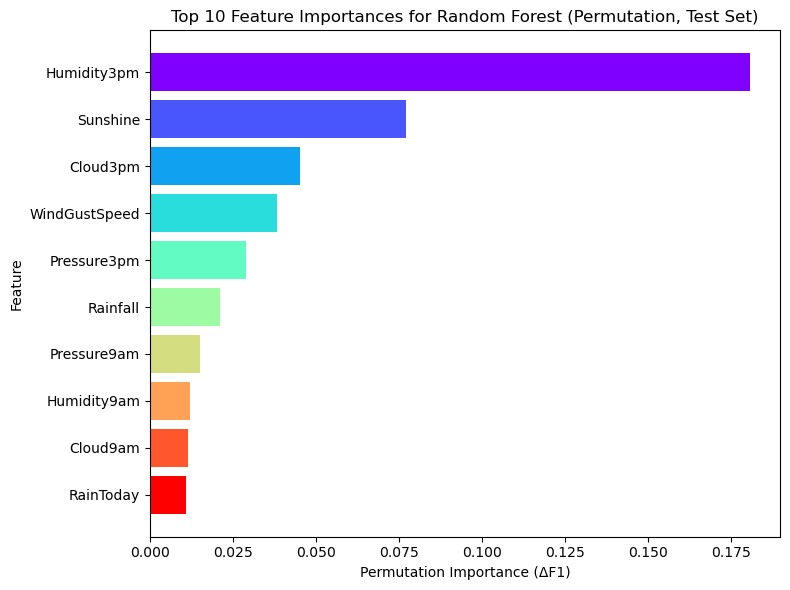


=== Permutation Importance for Logistic Regression ===
          Feature  Importance_Mean  Importance_Std
13    Humidity3pm         0.206806        0.005740
15    Pressure3pm         0.162004        0.006549
5        Sunshine         0.084469        0.006126
7   WindGustSpeed         0.078885        0.003313
17       Cloud3pm         0.029036        0.003548
14    Pressure9am         0.019035        0.004287
20      RainToday         0.016625        0.002060
18        Temp9am         0.006358        0.003147
3        Rainfall         0.005767        0.001332
19        Temp3pm         0.004531        0.002128
8      WindDir9am         0.004268        0.001851
12    Humidity9am         0.004065        0.001125
9      WindDir3pm         0.003630        0.001904
0        Location         0.003432        0.001619
10   WindSpeed9am         0.002957        0.000900


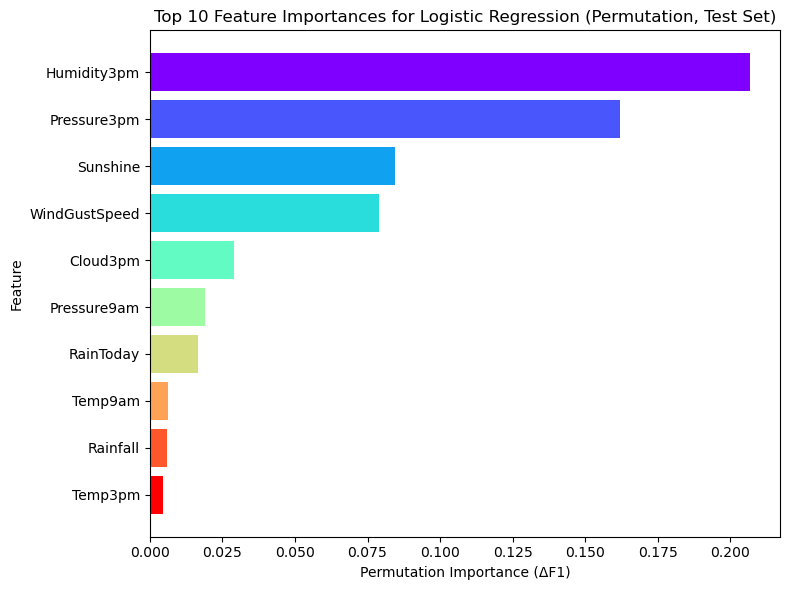


=== Permutation Importance for LightGBM ===
          Feature  Importance_Mean  Importance_Std
13    Humidity3pm         0.205137        0.005075
5        Sunshine         0.108189        0.004614
15    Pressure3pm         0.097045        0.003537
7   WindGustSpeed         0.061003        0.003618
17       Cloud3pm         0.024222        0.004845
3        Rainfall         0.024181        0.002093
0        Location         0.016047        0.002388
12    Humidity9am         0.004129        0.001454
9      WindDir3pm         0.001932        0.002969
14    Pressure9am         0.001783        0.003315
20      RainToday         0.001124        0.000299
18        Temp9am         0.000520        0.002804
23            Day         0.000000        0.000000
24        Weekday         0.000000        0.000000
22          Month         0.000000        0.000000


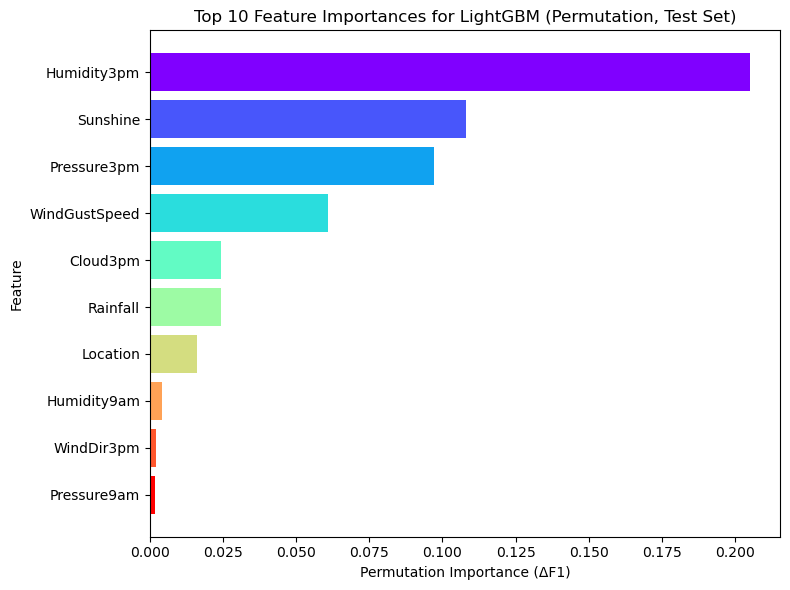


=== Permutation Importance for Neural Network (MLP) ===
          Feature  Importance_Mean  Importance_Std
13    Humidity3pm         0.251629        0.005948
15    Pressure3pm         0.176192        0.005991
5        Sunshine         0.118283        0.005935
7   WindGustSpeed         0.093230        0.003075
17       Cloud3pm         0.046820        0.005366
14    Pressure9am         0.025936        0.004945
2         MaxTemp         0.024931        0.002449
11   WindSpeed3pm         0.017600        0.001494
3        Rainfall         0.016305        0.002208
12    Humidity9am         0.015260        0.003970
16       Cloud9am         0.014805        0.002310
18        Temp9am         0.013035        0.003423
20      RainToday         0.009301        0.002588
19        Temp3pm         0.007759        0.002324
0        Location         0.007628        0.002031


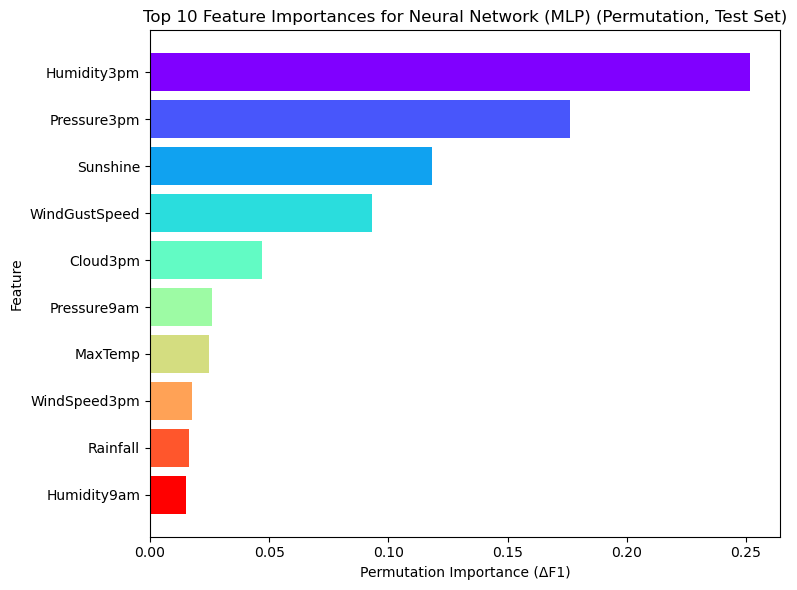


=== Permutation Importance for Stacking Ensemble ===
          Feature  Importance_Mean  Importance_Std
13    Humidity3pm         0.203645        0.004546
5        Sunshine         0.092839        0.004640
7   WindGustSpeed         0.050034        0.003423
15    Pressure3pm         0.041305        0.003277
17       Cloud3pm         0.030878        0.002621
3        Rainfall         0.020907        0.001923
0        Location         0.012529        0.002148
12    Humidity9am         0.007604        0.002221
9      WindDir3pm         0.006020        0.001735
8      WindDir9am         0.005751        0.001684
16       Cloud9am         0.003661        0.001726
20      RainToday         0.003537        0.000832
6     WindGustDir         0.002091        0.001381
2         MaxTemp         0.001054        0.002048
24        Weekday         0.000000        0.000000


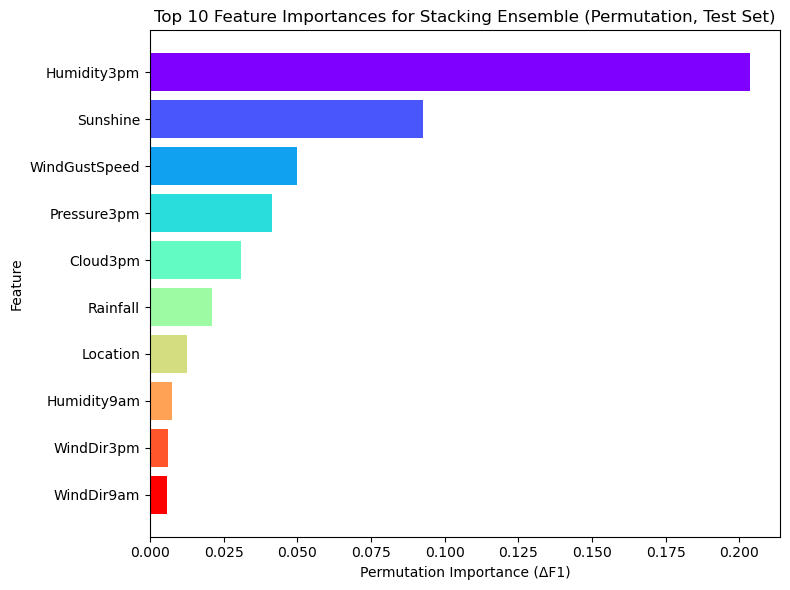

In [22]:
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer, f1_score
import pandas as pd
import matplotlib.pyplot as plt

# Scorer for permutation importance
f1_scorer = make_scorer(f1_score, pos_label=1, zero_division=0)

# Dictionary to store importance results for each model
all_importances = {}

for name, model in best_models.items():
    print(f"\n=== Permutation Importance for {name} ===")

    # Compute permutation importance on the TEST set
    perm = permutation_importance(
        estimator=model,          # full pipeline (preprocessing + model)
        X=X_test,
        y=y_test_encoded,
        scoring=f1_scorer,
        n_repeats=10,
        random_state=42,
        n_jobs=-1
    )

    # Convert to DataFrame
    fi_df = pd.DataFrame({
        "Feature": X_test.columns,
        "Importance_Mean": perm.importances_mean,
        "Importance_Std": perm.importances_std
    }).sort_values("Importance_Mean", ascending=False)

    all_importances[name] = fi_df

    print(fi_df.head(15))

    # Plot Top-15 features
    import matplotlib.pyplot as plt
    import numpy as np

    top_k = 10

    # Use a rainbow-style colormap
    cmap = plt.cm.rainbow   # or plt.cm.gist_rainbow
    colors = cmap(np.linspace(0, 1, top_k))

    plt.figure(figsize=(8, 6))

    plt.barh(
        fi_df["Feature"].head(top_k)[::-1],
        fi_df["Importance_Mean"].head(top_k)[::-1],
        color=colors[::-1]   # reverse so colors match feature order
    )

    plt.xlabel("Permutation Importance (ΔF1)")
    plt.ylabel("Feature")
    plt.title(f"Top {top_k} Feature Importances for {name} (Permutation, Test Set)")
    plt.tight_layout()
    plt.show()

#### **Model choice**
The key idea of Permutation Importance is: on the test set, we randomly shuffle one feature column (so the link between this feature and the target is broken), and then we observe how much the model performance drops (in this study, we use F1 for the positive class). A larger drop means the model depends more on this feature, so the feature is more important. This method works on the full Pipeline, so it can output feature importance for the original feature columns while keeping preprocessing consistent. This makes the results easier to interpret and compare.

#### **Experiment setup**
We use the test set for evaluation and use the best LightGBM Pipeline that is retrained on Train + Val. Since “rain tomorrow” is usually the minority class, F1 can better reflect the detection quality for rainy days, so we use ΔF1 as the evaluation metric. We set n_repeats = 10. For each feature, we repeat the permutation 10 times and take the average to reduce fluctuations caused by randomness.

#### **Result analysis**
The figure shows the top 15 features by permutation importance on the test set. Humidity3pm is much more important than all other variables. This means that shuffling only the Humidity3pm column causes the model’s F1 to drop by about 0.20 on average. It shows that the model strongly depends on “humidity at 3 pm” to predict the probability of rain on the next day. From a meteorology view, humidity directly reflects the amount of water vapor. Humidity in the afternoon can reflect cloud and rain development later in the day and how close the air is to saturation, so it provides a strong signal for predicting next-day rainfall.

Sunshine and Pressure3pm also have strong explanatory power. Shorter sunshine hours usually mean thicker clouds and less solar radiation, which is closely related to a higher chance of rainfall. The importance of Pressure3pm is clearly higher than Pressure9am, which suggests the model relies more on “afternoon pressure” as a signal of changes in the weather system. Low-pressure systems are often linked with rising air and unstable weather, which are important background conditions for rainfall.

WindGustSpeed, Cloud3pm, Rainfall, and Location show medium importance, and all are clearly above 0. This means they still make real contributions to model performance. WindGustSpeed can reflect the strength of the weather system and how active convection is, and it is often related to fronts and low-pressure systems. Cloud3pm directly describes cloud cover and is closely connected to the rainfall formation process. Rainfall represents today’s rainfall amount and can act as prior information for rain continuation. If it rains today, the chance of rain tomorrow often increases. Location is converted by Target Encoding into a continuous value related to rainfall rate, which captures regional climate differences (for example coastal vs inland, or different climate zones). Therefore, it provides a stable gain for prediction.

#### **Robustness analysis**
The standard deviation of importance for the top features is generally small (about 0.001 to 0.004). This shows that under 10 repeated permutations, the importance estimates are stable, so the conclusions are reliable. In particular, Humidity3pm, Sunshine, and Pressure3pm have both high mean importance and low variation, which suggests they contribute consistently and robustly to the model’s predictions.

<a id='section8'></a>
## 8. Conclusions & Next Steps

#### **Summary of overall process**
This project builds a binary classification framework to predict RainTomorrow (whether it will rain tomorrow) based on historical weather observations in Australia. The overall workflow has five stages: **EDA** → **data processing and feature engineering** → **modeling and tuning** → **final evaluation** → **interpretability analysis**.
##### 1.**EDA**
In the EDA stage, we systematically checked data quality and distribution patterns, including the class ratio of the target, missing value patterns, distributions and skewness of key weather features (such as humidity, pressure, sunshine, and rainfall), relationships between variables and the target, and differences across categorical features such as Location. The main EDA findings guided later modeling. For example, the dataset has clear missing values (especially in some weather variables), so we needed a clear missing-value strategy. The target class (**RainTomorrow**) is somewhat imbalanced, so evaluation should focus on **F1, Recall, and Balanced Accuracy**. Variables like humidity, pressure, sunshine, and cloud cover are strongly related to rainfall. Location reflects regional climate differences and is a high-cardinality categorical feature, so it needs proper encoding.
##### 2.**Data cleaning and feature engineering**
After loading the data, we decomposed the date into time features such as **Year, Month, Day, and Weekday**. We set cloud-related variables as categorical features and removed samples with missing target values. Then we identified high-cardinality categorical features (such as Location and wind directions) and low-cardinality categorical features (such as RainToday and some cloud-related variables), and designed the encoding strategy based on this.
##### 3.**Data splitting and target encoding**
We used stratified sampling to split the data into **Train, Validation, and Test sets**. Before target encoding, we reset the index to avoid misalignment between features and labels during cross-validation, which helps ensure reliable evaluation.
##### 4.**Preprocessing pipeline and model comparison**
We built a unified preprocessing pipeline using **Pipeline + ColumnTransformer**, including numeric standardization, One-Hot encoding for low-cardinality features, Target Encoding for high-cardinality features, and ordinal encoding for ordered categorical variables. Under this unified input setting, we trained and compared several models, including **Random Forest, Logistic Regression, LightGBM, MLP, and Stacking**.
##### 5.**Hyperparameter tuning, final training, and test evaluation**
We used RandomizedSearchCV (5-fold cross-validation, optimizing positive-class F1) for tuning and selected the best model based on validation results. The final model is LightGBM. After retraining it on the combined Train+Val data, we achieved the following results on the test set: **F1 = 0.652, Precision = 0.765, Recall = 0.567, Balanced Accuracy = 0.759**.
##### 6.**Interpretability analysis**
On the test set, we used permutation importance (ΔF1) to evaluate feature importance. The results show that **Humidity3pm, Sunshine, and Pressure3pm** are the most important features, and this is consistent with the weather patterns observed in the EDA stage.

#### **What worked well**
##### 1.**EDA guided our modeling decisions like a “navigation tool”**
EDA helped us identify the main challenges in the data, including missing values, class imbalance, and high-cardinality categorical features. It also highlighted strong signal variables such as humidity, pressure, sunshine, and cloud cover. Based on these findings, we made several key decisions. We used a more robust missing-value strategy (finally choosing dropna or a robust imputation approach). We focused on metrics that fit imbalanced data better, such as positive-class F1 and Balanced Accuracy. We also applied Target Encoding to high-cardinality features like Location to avoid a large feature space caused by One-Hot encoding.

##### 2.**LightGBM performed best on this tabular task and generalized well**
After hyperparameter tuning, LightGBM achieved the highest cross-validation F1 score, and its test performance stayed at a similar level (F1 about 0.652). This suggests the model is stable and works well on unseen data.

##### 3.**A unified preprocessing Pipeline improved fairness, reproducibility, and reduced leakage risk**
By wrapping preprocessing and the model into one Pipeline, we ensured that cross-validation and test evaluation followed the same process. This reduces bias caused by manual differences and also lowers the risk of data leakage.

##### 4.**Interpretability results matched the EDA observations and increased trust in the model**
Permutation importance shows that Humidity3pm (ΔF1 about 0.204) is the most important feature by a large margin, followed by Sunshine and Pressure3pm. This is consistent with the EDA findings that humidity, pressure, and sunshine are strongly related to rainfall. This agreement suggests the model learned reasonable patterns and makes the results more trustworthy.

#### **Project limitations and improvements**
##### 1.**Class imbalance still limits Recall**
Although Precision is high (0.765), Recall is 0.567. This means the model still misses some rainy days. In risk-sensitive settings, this may require further improvement. 

**Action**: Add imbalance handling in LightGBM, such as scale_pos_weight = (#negative / #positive) or is_unbalance = True, to increase the learning focus on the positive class.

##### 2.**Random splitting may underestimate the difficulty of time generalization**
Weather data has clear seasonality and time dependence. A random split may make the training and test sets too similar, so the evaluation can be too optimistic.  

**Action**: Use TimeSeriesSplit for cross-validation and report performance changes across different time folds. Maybe can also add seasonal feature interactions (such as Month × Location) and check whether they improve stability across years.

##### 3.**Permutation importance alone cannot explain the direction of effects**
Permutation importance can show whether a feature is important, but it cannot directly tell whether a higher feature value increases or decreases the rain probability. Also, correlated features can replace each other, which may make importance values look smaller.  

**Action**: Add SHAP analysis (both global and local) to provide direction and contribution explanations.